# Monte Carlo Simulations

In this notebook, I run Monte Carlo simulations and view the results of varying alpha/beta/gamma.

In [1]:
# Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

"/Users/jananidhileepan/Desktop/Don't. Even./University/Imperial College London/Year 2/Dissertation/GitHub/fairness_smoke_alarm/src"

In [3]:
from changepoint_detection_functions import (
    CUSUMDetector,
    referee_cusum,
    EWMAResidualDetector,
    referee_ewma,
    and_or_gate,
    and_or_gate_referee,
    miss_rate
)

from fairness_metrics import unfairness_score

## 1. Convert boostrapped standard errors to a 3x3 matrix

In [4]:
boot_df = pd.read_csv("../data/processed/bootstrap.csv", index_col = 0)

Sigma = np.cov(boot_df[["DP", "EO", "CAL"]].values, rowvar=False)

In [5]:
def sigma_hat(w, Sigma):
    return np.sqrt(w @ Sigma @ w)

w = np.array([1/3, 1/3, 1/3])
sigma_hat(w, Sigma)

0.0004917382180160006

## 2. Load the fairness data and build the four referees

In [6]:
df_fairness = pd.read_csv("../data/processed/fairness_numbers.csv", index_col=0)

referee_cusum_alarm, detectors_cusum = referee_cusum(df_fairness, boot_df)
referee_ewma_alarm,  detectors_ewma  = referee_ewma(df_fairness, boot_df)

referee_and = and_or_gate_referee(detectors_cusum, detectors_ewma, gate="and")
referee_or  = and_or_gate_referee(detectors_cusum, detectors_ewma, gate="or")

## 3. Create function to evaluate all fairness metrics for a given weighting

In [7]:
def evaluate_weighting(alpha, beta, gamma, df_fairness, Sigma,
                       referee_cusum_alarm, referee_ewma_alarm,
                       referee_and, referee_or,
                       k=0.5, h=4.77, baseline_year=2007):

    composite = unfairness_score(df_fairness, alpha, beta, gamma) # weights passed
    w = np.array([alpha, beta, gamma]) # order: DP, EO, CAL
    se = sigma_hat(w, Sigma)

    cus = CUSUMDetector(composite, sigma_hat=se, k=k, h=h, baseline_year=baseline_year)
    cus.run()

    ewm = EWMAResidualDetector(composite, sigma_hat=se, baseline_year=baseline_year)
    ewm.run()

    and_alarm = and_or_gate(cus, ewm, gate="and")
    or_alarm  = and_or_gate(cus, ewm, gate="or")

    weights = {"alpha": alpha, "beta": beta, "gamma": gamma, "sigma_hat": se}

    return [
        miss_rate(cus.alarm,  referee_cusum_alarm, variant="cusum", **weights),
        miss_rate(ewm.alarm,  referee_ewma_alarm,  variant="ewma",  **weights),
        miss_rate(and_alarm,  referee_and,         variant="and",   **weights),
        miss_rate(or_alarm,   referee_or,          variant="or",    **weights),
    ]

In [8]:
def show(rows):
    return (pd.DataFrame(rows)
              [["variant", "miss_rate", "first_alarm_year",
                "n_transitions", "referee_flagged_years"]]
              .round(3))

In [10]:
composite_evaluation = evaluate_weighting(alpha = 1/3, beta = 1/3, gamma = 1/3, df_fairness = df_fairness, Sigma = Sigma,
                   referee_cusum_alarm = referee_cusum_alarm, referee_ewma_alarm = referee_ewma_alarm,
                   referee_and = referee_and, referee_or = referee_or)

show(composite_evaluation)

,variant,miss_rate,first_alarm_year,n_transitions,referee_flagged_years
0,cusum,0.222,2011,1,9
1,ewma,0.286,2010,3,7
2,and,0.429,2011,3,7
3,or,0.111,2010,1,9


## 4. Monte Carlo

In [ ]:
rng = np.random.default_rng(0)
weights = rng.dirichlet([1, 1, 1], size=2000) # 2000 draws
weights.shape # (2000, 3)

weights.sum(axis=1).min(), weights.sum(axis=1).max() # At 1, as expected

(0.9999999999999998, 1.0000000000000002)

In [ ]:
results = []
for alpha, beta, gamma in weights:
    results.extend(evaluate_weighting(
        alpha, beta, gamma,
        df_fairness, Sigma,
        referee_cusum_alarm, referee_ewma_alarm,
        referee_and, referee_or,
    ))

df_mc = pd.DataFrame(results)

summary = df_mc.groupby("variant")["miss_rate"].agg(
    mean="mean",
    sd="std",
    n="count",
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary.round(4)

,mean,sd,n,se
variant,,,,
and,0.4954,0.4004,2000,0.0090
cusum,0.4237,0.4284,2000,0.0096
ewma,0.3266,0.2418,2000,0.0054
or,0.2923,0.3004,2000,0.0067


#### Analyse results

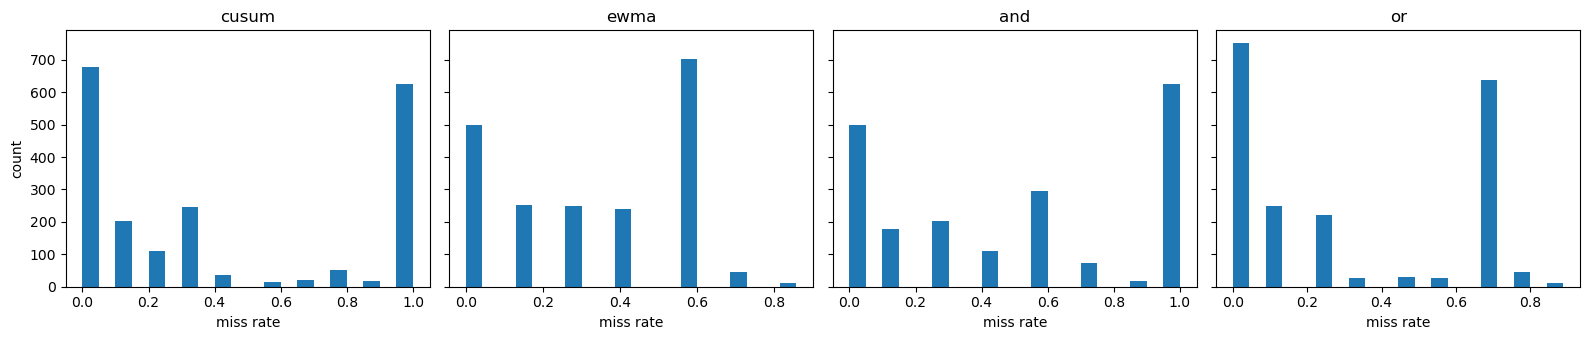

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):
    sub = df_mc[df_mc["variant"] == variant]["miss_rate"]
    ax.hist(sub, bins=20)
    ax.set_title(variant)
    ax.set_xlabel("miss rate")

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

In [ ]:
df_mc.groupby("variant")["miss_rate"].agg(
    frac_perfect=lambda s: (s == 0).mean(),
    frac_total_failure=lambda s: (s == 1).mean(),
    worst=lambda s: s.max(),
).round(3)

,frac_perfect,frac_total_failure,worst
variant,,,
and,0.250,0.312,1.000
cusum,0.338,0.312,1.000
ewma,0.250,0.000,0.857
or,0.376,0.000,0.889


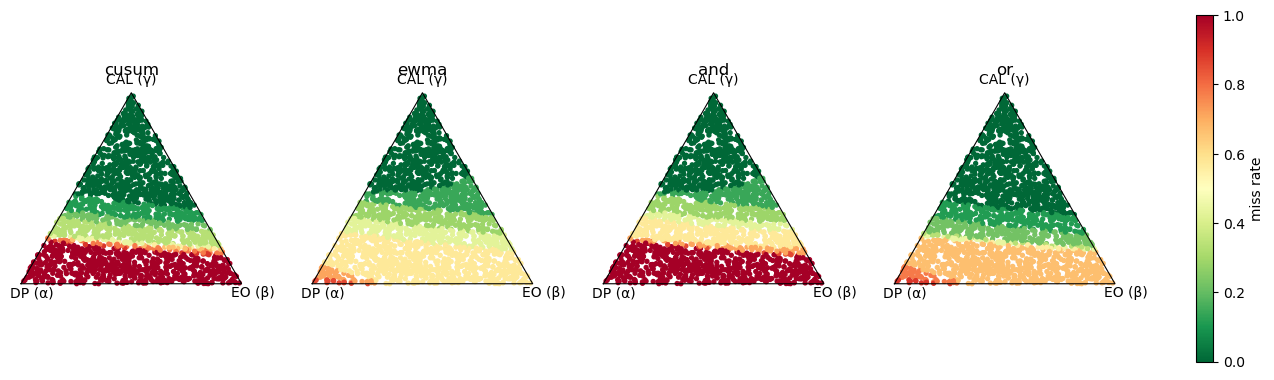

In [ ]:
def to_xy(a, b, g):
    return b + g/2, g * np.sqrt(3)/2

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):
    sub = df_mc[df_mc["variant"] == variant]
    x, y = to_xy(sub["alpha"], sub["beta"], sub["gamma"])
    pts = ax.scatter(x, y, c=sub["miss_rate"], cmap="RdYlGn_r",
                     s=8, vmin=0, vmax=1)
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], color="k", lw=0.8)
    ax.set_title(variant)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.text(-0.05, -0.06, "DP (α)")
    ax.text(0.95, -0.06, "EO (β)")
    ax.text(0.5, np.sqrt(3)/2 + 0.04, "CAL (γ)", ha="center")

fig.colorbar(pts, ax=axes, label="miss rate")
plt.show()

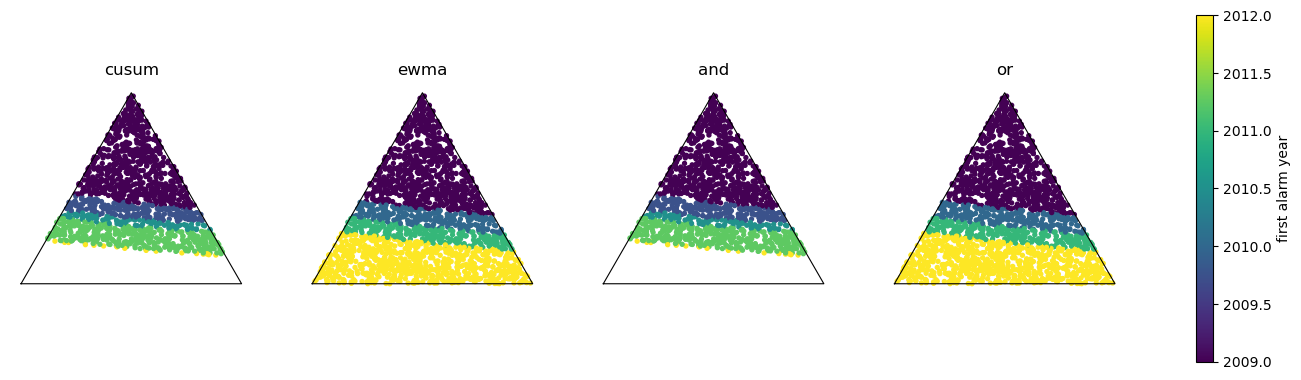

In [ ]:
# Plot the delay in alarm - white means no alarm

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, variant in zip(axes, ["cusum", "ewma", "and", "or"]):
    sub = df_mc[df_mc["variant"] == variant]
    x, y = to_xy(sub["alpha"], sub["beta"], sub["gamma"])
    pts = ax.scatter(x, y, c=sub["first_alarm_year"], cmap="viridis", s=8)
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], color="k", lw=0.8)
    ax.set_title(variant); ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(pts, ax=axes, label="first alarm year")
plt.show()

In [ ]:
df_mc.to_csv("../data/processed/mc_results.csv")

## Monte Carlo over the (α, β, γ) simplex — findings, 23 July

### Setup
- 2000 weightings drawn from Dirichlet(1,1,1), seed 0. Uniform over the simplex,
  i.e. the formal statement of "the regulation gives no reason to prefer any weighting".
- Σ from the 200 bootstrap resamples on 2007; σ̂(w) = sqrt(wᵀΣw), verified to 14 s.f.
  against the earlier direct calculation.
- Four detector variants (CUSUM, EWMA-residual, AND, OR), k = 0.5, h = 4.77.
- Each variant scored against its own referee, so differences reflect the weighting
  rather than differences between referees.
- Validation: uniform weights reproduce the previously confirmed CUSUM miss rate of 0.222.

### Result 1 — the outcome is close to all-or-nothing, not a gradient
CUSUM: mean miss rate 0.424, sd 0.428. For a quantity bounded in [0, 1] that is
roughly 87% of the maximum possible sd at that mean.
Breakdown: 34% of weightings miss nothing, 31% miss everything, 35% in between.
The mean describes almost none of the actual outcomes and should not be reported alone.

### Result 2 — the transition is a cliff, not a slope
Performance changes abruptly at roughly γ ≈ 0.17 rather than degrading gradually.
Two deployers choosing γ = 0.15 and γ = 0.20 have made near-identical decisions and
obtained opposite monitors.

### Result 3 — the failing region is where regulatory instinct points
The red region is the DP corner. Demographic parity is the metric closest to
disparate-impact doctrine and the four-fifths rule, so it is the weighting a
good-faith 2007 compliance function would most plausibly favour. The alarm works
only if weight is placed on calibration, which no legal instinct recommends.
[Check: is this overstated? Needs support from the fair-lending literature.]

### Result 4 — the DP/EO collapse, predicted algebraically, confirmed empirically
Colour varies vertically (with γ) and is near-constant horizontally along bands.
Since DP and EO move near-identically across years, α and β enter the composite
drift only through their sum, so the detector depends on γ alone.
Caveat: this holds in the numerator only. In the bootstrap covariance, DP is ~5x
noisier than EO, so the α/β split does affect σ̂ and hence the threshold.

### Result 5 — EWMA cannot be driven to total failure, but is slow
EWMA and OR never exceed miss rates of 0.857 and 0.889; CUSUM and AND both reach 1.0.
However, weightings that never alarm under CUSUM alarm in 2012 under EWMA — five
years after the referee's first flag. Late detection is currently scored as success
by the miss rate; a delay measure is needed.
[Do not generalise: the floor under EWMA likely depends on the 2007 anchor sitting
at the DP/EO peak, which is a feature of the crisis rather than of adaptive detectors.]

### Framing note
The contribution is structural and does not depend on the specific values of
DP/EO/CAL. The magnitudes here are specific to this model and dataset; the mechanism
is not. The optimal weighting is a function of future drift, which is unavailable at
the time the choice must be made.

### Open items
1. Check whether CAL's individual detector drives most of the referee's 9 flagged
   years. If so, "weight CAL heavily" may score well partly by imitating the referee.
2. Add detection delay (first alarm year − referee's first flagged year) alongside miss rate.
3. Store per-year alarms to plot alarm coverage over time.
4. Robustness: refit with a stronger model, regenerate the three series, re-run the
   sweep. Tests whether the DP/EO collapse and the cliff survive higher accuracy.
5. Threshold robustness at h = 4σ and 5σ.